# Importing the needed libraries

In [ ]:
pip install nltk

In [ ]:
pip install networkx

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk as nk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import euclidean, cityblock, cosine
import networkx as nx
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.cluster import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans, HDBSCAN, MeanShift, AffinityPropagation, MiniBatchKMeans, AgglomerativeClustering, BisectingKMeans, DBSCAN, HDBSCAN, OPTICS


In [ ]:
nk.download('punkt_tab')
nk.download('stopwords')

# Reading the dataset and exploring it

In [ ]:
df = pd.read_csv('/content/Final_students_data (1).csv')

In [ ]:
df.head()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df.dtypes

In [ ]:
df.shape

# Creating the methods needed for text mining in order to make the code more effecient

**removing the stop words method:**

In [ ]:
stop_words = set(stopwords.words('english'))
def stopword_remove(x):
  return [W for W in x if not W.lower() in stop_words]

**removing punctuation method:**

In [ ]:
punctuation = set(string.punctuation)
def punctuation_remove(x):
  return [W for W in x if not W in punctuation]

**Converting the text to lower case method:**

In [ ]:
def convert_lower(x):
  return [W.lower() for W in x]

**stemming method:**

In [ ]:
st = PorterStemmer()
def stem(x):
  return [st.stem(W) for W in x]

**combining all of the methods and adding the tokenizatin and joining steps**

In [ ]:
def TM_prep (query):

  query = word_tokenize(query)

  query = stopword_remove(query)

  query = punctuation_remove(query)

  query = convert_lower(query)

  query = stem(query)

  query = ' '.join(query)
  return query

**Calculating TF-IDF method**

In [ ]:
vect = TfidfVectorizer()

def TF_IDF_text (text):

  TF_IDF_Matrix = vect.fit_transform(text)
  TF_IDF_Array = TF_IDF_Matrix.toarray()

  for i, bio in enumerate(text):

    TF_IDF = TF_IDF_Array[i]

    dict = {vect.get_feature_names_out()[j]: TF_IDF[j] for j in range(len(TF_IDF))}

    return dict, TF_IDF_Array, TF_IDF_Matrix

In [ ]:
def TF_IDF_query (query):

  TF_IDF_Matrix = vect.transform(query)
  TF_IDF_Array = TF_IDF_Matrix.toarray()

  for i, bio in enumerate(query):

    TF_IDF = TF_IDF_Array[i]

    dict = {vect.get_feature_names_out()[j]: TF_IDF[j] for j in range(len(TF_IDF))}

    return dict, TF_IDF_Array, TF_IDF_Matrix

**printing the TF-IDF values method:**

In [ ]:
def display_TFIDF (text,dict):
  for i, bio in enumerate(text):
      print(f"Calculated TF-IDF for doc {i+1}:")
      for word, tfidf in dict.items():
           print(f"{word}: {tfidf}")
      print()

**calculating smilirty mesuers method:**

In [ ]:
def similarity_mesuers(query_matrix,Bio_matrix):

  similarity_results = []

  for idx, doc_vec in enumerate(Bio_matrix):
      manhattan_dist = cityblock(query_matrix.toarray()[0], doc_vec.toarray()[0])
      euclidean_dist = euclidean(query_matrix.toarray()[0], doc_vec.toarray()[0])
      if np.linalg.norm(query_matrix.toarray()[0]) == 0 or np.linalg.norm(doc_vec.toarray()[0]) == 0 :
        cosine_sim = 0
      else:
        cosine_sim = 1 - cosine(query_matrix.toarray()[0], doc_vec.toarray()[0])

      similarity_results.append({
          'Document': f'bio{idx + 1}',
          'Manhattan Distance': manhattan_dist,
          'Euclidean Distance': euclidean_dist,
          'Cosine Similarity': cosine_sim
      })

  similarity_df = pd.DataFrame(similarity_results)
  return similarity_df

# Applying Text mining using the TF-IDF teqhnique

**preparing the bios for calculating TF-IDF**

In [ ]:
df["Bio_ready"] = df["Bio"].apply(lambda i:TM_prep(i))

In [ ]:
df.head()

**calculating TF-IDF for the bios**

In [ ]:
Bio_dict, Bio_TFIDF_Array, Bio_TFIDF_Matrix = TF_IDF_text(df["Bio_ready"])

In [ ]:
display_TFIDF(df["Bio_ready"],Bio_dict)

# Query one

In [ ]:
q1 =  "cake shop"

In [ ]:
q1 = TM_prep(q1)
print(q1)

**calculating the TF-IDF**

In [ ]:
query1_dict, query1_TFID_Array, query1_TFID_Matrix = TF_IDF_query([q1])

In [ ]:
display_TFIDF(q1,query1_dict)

**similarity mesuers**


In [ ]:
q1_similarty = similarity_mesuers(query1_TFID_Matrix,Bio_TFIDF_Matrix)
q1_similarty

**displaying bios that are relavent to the  query using cosine similarity**

In [ ]:
q1_cosine_df = q1_similarty.drop(['Manhattan Distance','Euclidean Distance'], axis=1)
q1_cosine_df = q1_cosine_df[q1_cosine_df["Cosine Similarity"] > 0.0]

In [ ]:
q1_cosine_df["Document"] = q1_cosine_df["Document"].apply(lambda i:i.replace("bio",""))
q1_cosine_df["Document"] = q1_cosine_df["Document"].apply(lambda i:int(i))
q1_cosine_df = q1_cosine_df.sort_values("Cosine Similarity", ascending=False)
q1_cosine_df

In [ ]:
if  not q1_cosine_df.empty:
  for i in q1_cosine_df["Document"]:
    print(df.loc[i-1,"Bio"])
    print()
else:
    print("There are no bios that matches your describtion")

# Query two

In [ ]:
q2 =  "Data Science and AI student in Jordan."

In [ ]:
q2 = TM_prep(q2)
print(q2)

**calculating the TF-IDF**

In [ ]:
query2_dict, query2_TFID_Array, query2_TFID_Matrix = TF_IDF_query([q2])

In [ ]:
display_TFIDF(q2,query2_dict)

**similarity mesuers**


In [ ]:
q2_similarty = similarity_mesuers(query2_TFID_Matrix,Bio_TFIDF_Matrix)
q2_similarty

**displaying bios that are relavent to the  query using cosine similarity**

In [ ]:
q2_cosine_df = q2_similarty.drop(['Manhattan Distance','Euclidean Distance'], axis=1)
q2_cosine_df = q2_cosine_df[q2_cosine_df["Cosine Similarity"] > 0.0]

In [ ]:
q2_cosine_df["Document"] = q2_cosine_df["Document"].apply(lambda i:i.replace("bio",""))
q2_cosine_df["Document"] = q2_cosine_df["Document"].apply(lambda i:int(i))
q2_cosine_df = q2_cosine_df.sort_values("Cosine Similarity", ascending=False)
q2_cosine_df

In [ ]:
if  not q2_cosine_df.empty:
  for i in q2_cosine_df["Document"]:
      print(df.loc[i-1,"Bio"])
      print()
else:
    print("There are no bios that matches your describtion")

# Query three

In [ ]:
q3 =  "forth year student in Jordan."

In [ ]:
q3 = TM_prep(q3)
print(q3)

**calculating the TF-IDF**

In [ ]:
query3_dict, query3_TFID_Array, query3_TFID_Matrix = TF_IDF_query([q3])

In [ ]:
display_TFIDF(q3,query3_dict)

**similarity mesuers**


In [ ]:
q3_similarty = similarity_mesuers(query3_TFID_Matrix,Bio_TFIDF_Matrix)
q3_similarty

**displaying bios that are relavent to the  query using cosine similarity**

In [ ]:
q3_cosine_df = q3_similarty.drop(['Manhattan Distance','Euclidean Distance'], axis=1)
q3_cosine_df = q3_cosine_df[q3_cosine_df["Cosine Similarity"] > 0.0]

In [ ]:
q3_cosine_df["Document"] = q3_cosine_df["Document"].apply(lambda i:i.replace("bio",""))
q3_cosine_df["Document"] = q3_cosine_df["Document"].apply(lambda i:int(i))
q3_cosine_df = q3_cosine_df.sort_values("Cosine Similarity", ascending=False)
q3_cosine_df

In [ ]:
if  not q3_cosine_df.empty:
  for i in q3_cosine_df["Document"]:
    print(df.loc[i-1,"Bio"])
    print()
else:
    print("There are no bios that matches your describtion")

# Query four

In [ ]:
q4 =  "Third year cybersecurity student in Jordan."

In [ ]:
q4 = TM_prep(q4)
print(q4)

**calculating the TF-IDF**

In [ ]:
query4_dict, query4_TFID_Array, query4_TFID_Matrix = TF_IDF_query([q4])

In [ ]:
display_TFIDF(q4,query4_dict)

**similarity mesuers**


In [ ]:
q4_similarty = similarity_mesuers(query4_TFID_Matrix,Bio_TFIDF_Matrix)
q4_similarty

**displaying bios that are relavent to the  query using cosine similarity**

In [ ]:
q4_cosine_df = q4_similarty.drop(['Manhattan Distance','Euclidean Distance'], axis=1)
q4_cosine_df = q4_cosine_df[q4_cosine_df["Cosine Similarity"] > 0.0]

In [ ]:
q4_cosine_df["Document"] = q4_cosine_df["Document"].apply(lambda i:i.replace("bio",""))
q4_cosine_df["Document"] = q4_cosine_df["Document"].apply(lambda i:int(i))
q4_cosine_df = q4_cosine_df.sort_values("Cosine Similarity", ascending=False)
q4_cosine_df

In [ ]:
if  not q4_cosine_df.empty:
  for i in q4_cosine_df["Document"]:
    print(df.loc[i-1,"Bio"])
    print()
else:
    print("There are no bios that matches your describtion")

# Query five

In [ ]:
q5 =  "Jordan university AI graduate student."

In [ ]:
q5 = TM_prep(q5)
print(q5)

**calculating the TF-IDF**

In [ ]:
query5_dict, query5_TFID_Array, query5_TFID_Matrix = TF_IDF_query([q5])

In [ ]:
display_TFIDF(q4,query5_dict)

**similarity mesuers**


In [ ]:
q5_similarty = similarity_mesuers(query5_TFID_Matrix,Bio_TFIDF_Matrix)
q5_similarty

**displaying bios that are relavent to the  query using cosine similarity**

In [ ]:
q5_cosine_df = q5_similarty.drop(['Manhattan Distance','Euclidean Distance'], axis=1)
q5_cosine_df = q5_cosine_df[q5_cosine_df["Cosine Similarity"] > 0.0]

In [ ]:
q5_cosine_df["Document"] = q5_cosine_df["Document"].apply(lambda i:i.replace("bio",""))
q5_cosine_df["Document"] = q5_cosine_df["Document"].apply(lambda i:int(i))
q5_cosine_df = q5_cosine_df.sort_values("Cosine Similarity", ascending=False)
q5_cosine_df

In [ ]:
if  not q5_cosine_df.empty:
  for i in q5_cosine_df["Document"]:
      print(df.loc[i-1,"Bio"])
      print()
else:
    print("There are no bios that matches your describtion")

# text mining application for a real-world issue

In [ ]:
user_query = input("what students are you searching for ?")

In [ ]:
query_ready = TM_prep(user_query)

In [ ]:
query_dict, query_array, query_matrix = TF_IDF_query([query_ready])

In [ ]:
results =[]
for idx, doc_vec in enumerate(Bio_TFIDF_Matrix):
      if np.linalg.norm(query_matrix.toarray()[0]) == 0 or np.linalg.norm(doc_vec.toarray()[0]) == 0 :
        cosine_sim = 0
      else:
        cosine_sim = 1 - cosine(query_matrix.toarray()[0], doc_vec.toarray()[0])
      results.append({
          'Document': int (idx + 1),

          'Cosine Similarity': cosine_sim
      })

results = pd.DataFrame(results)

In [ ]:
results = results.sort_values("Cosine Similarity", ascending=False)

In [ ]:
results

**testing multiple threshold values to know which one is the best to be used**

In [ ]:
result_threshold1 = results[results["Cosine Similarity"] >=0.2 ]

In [ ]:
if not result_threshold1.empty:
  for i in result_threshold1["Document"]:
      print(df.loc[i-1,"Bio"])
      print()
else:
    print("No related bios")

when assighning the threshold to 0.2 we can notice that the results were not close enough to the users query

In [ ]:
result_threshold2 = results[results["Cosine Similarity"] >= 0.25  ]

In [ ]:
if not result_threshold2.empty:
  for i in result_threshold2["Document"]:
      print(df.loc[i-1,"Bio"])
      print()
else:
    print("No related bios")

when assighning the threshold to 0.25 we can notice that the results were close to the user query but not exactly what he asked for

**best threshold that will be used:**

In [ ]:
result_threshold3 = results[results["Cosine Similarity"] >= 0.43 ]

In [ ]:
if not result_threshold3.empty:
  for i in result_threshold3["Document"]:
      print(df.loc[i-1,"Bio"])
      print()
else:
    print("No related bios")

 the third threshold is the best and the one chosen because it returned the bios that matches the users query exactly or was really close

**testing screenshots**

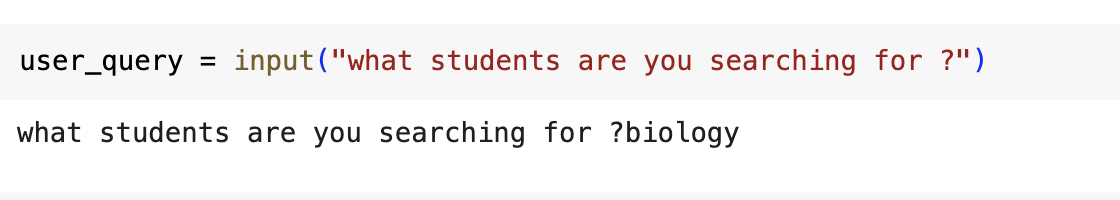

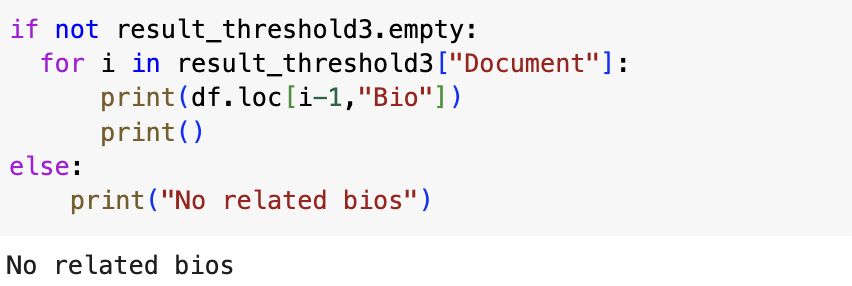

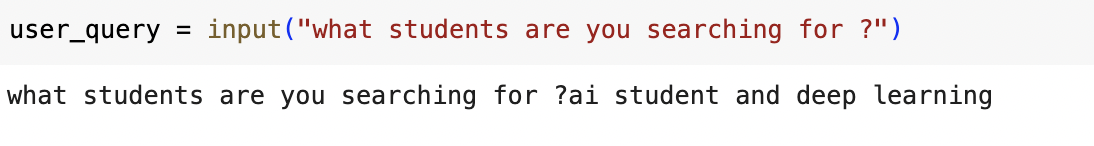

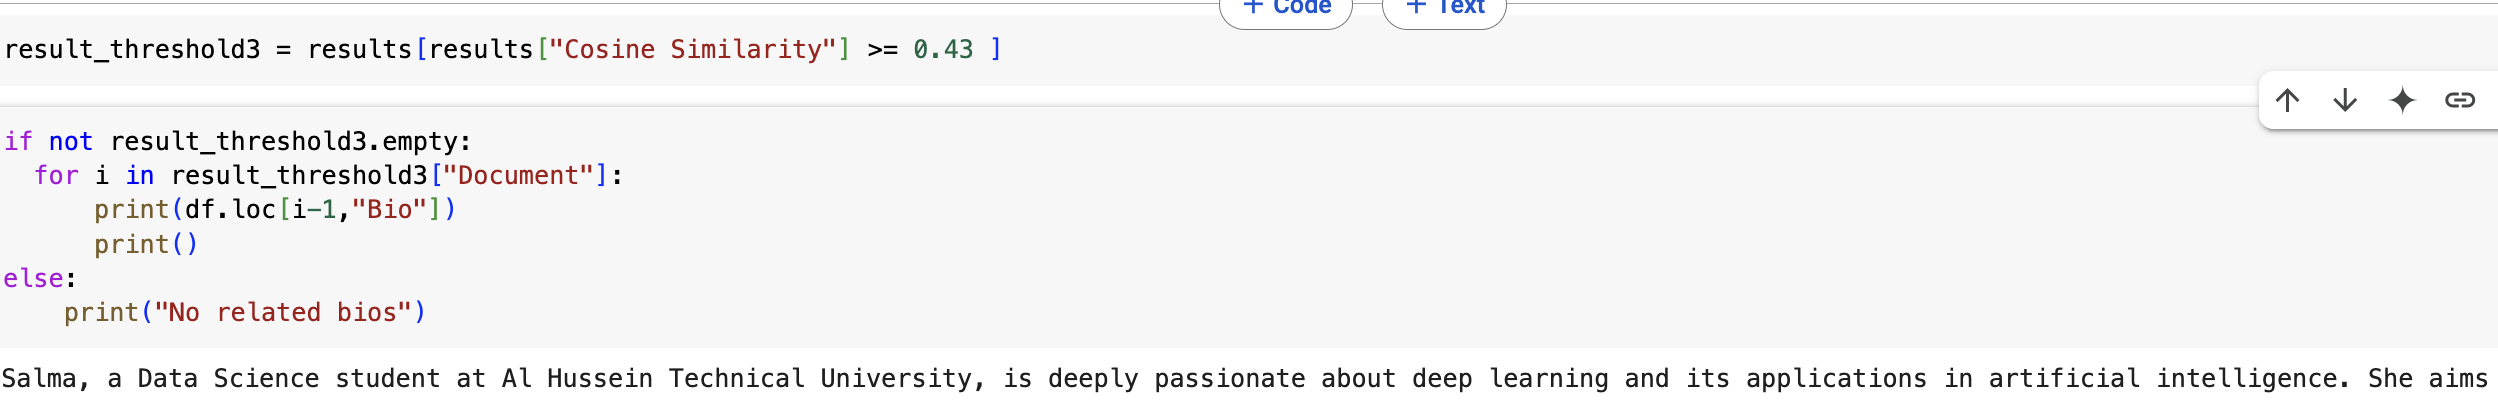

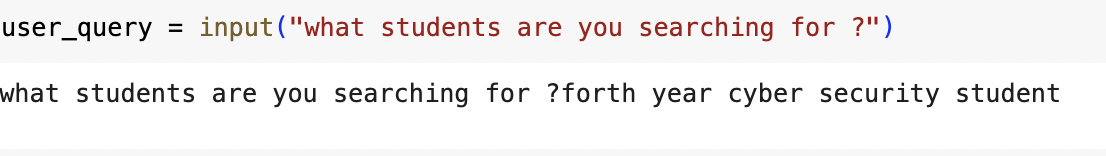

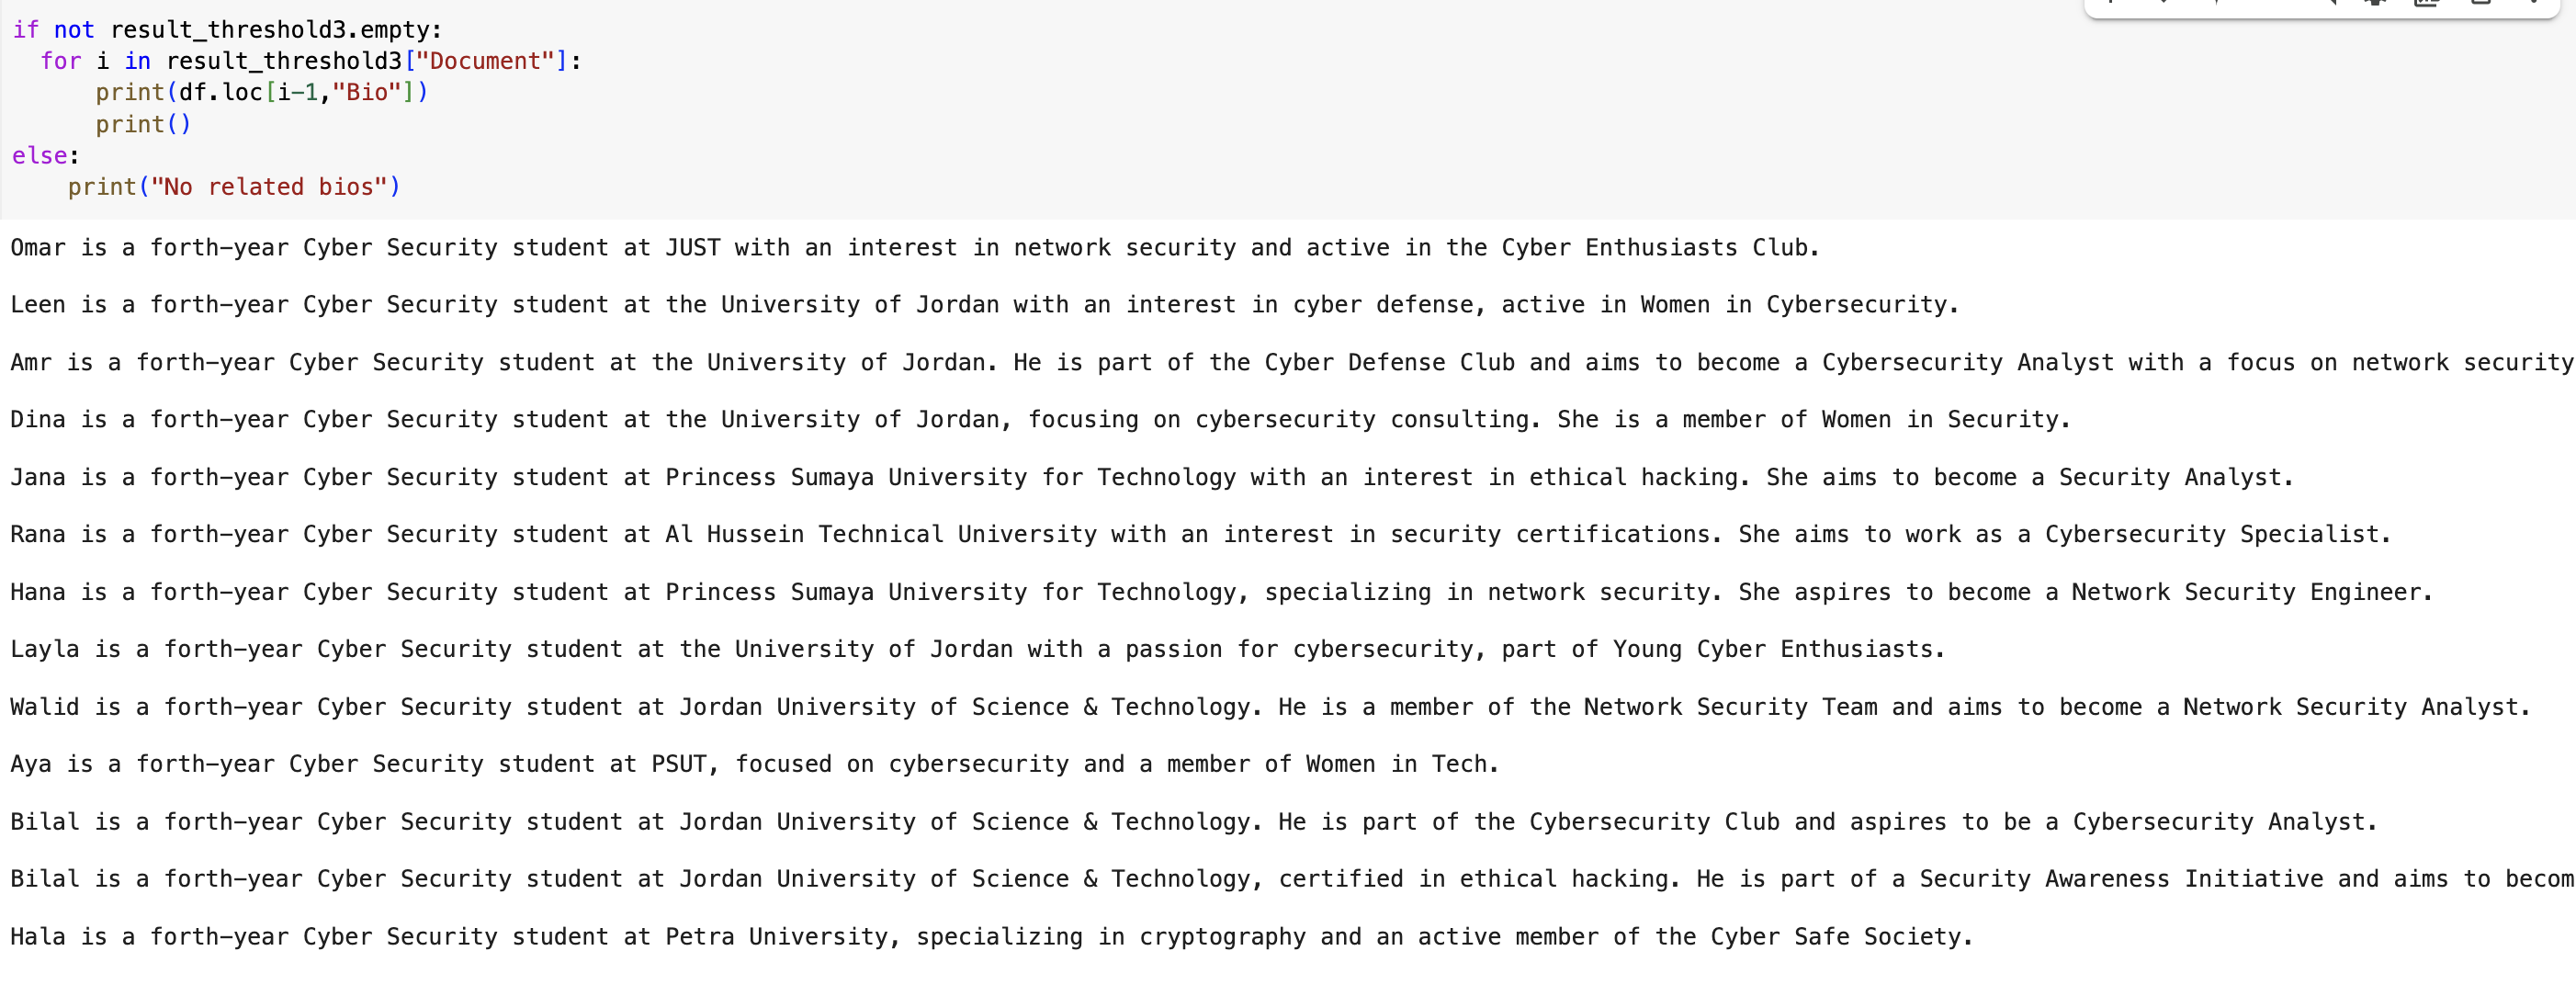

# Graph mining

In [ ]:
G = nx.DiGraph()

In [ ]:
student_name = df["Name"][0]
programming_language = df["Programming Languages"][0]
programming_language = programming_language.split(";")
programming_language.append(student_name)
print(programming_language)

In [ ]:
G.add_nodes_from(programming_language)

In [ ]:
edges = [(programming_language[-1], programming_language[0]),
          (programming_language[-1], programming_language[1]),
          (programming_language[-1], programming_language[2])]
G.add_edges_from(edges)

In [ ]:
pos = nx.spring_layout(G)
nx.draw(G, pos,
        with_labels=True, arrows=True,
        arrowsize=20,
        node_size=2000,
        node_color='skyblue',
        font_size=10, font_color='black', font_weight='bold', edge_color='gray', linewidths=1)


plt.savefig("Graph.png", format="PNG")
plt.show(block=False)

# graph mining real life scenario

In [ ]:
certificate = input("enter the name of the certificate:")

In [ ]:
certificate= certificate.lower()
df["Certifications"]= df["Certifications"].apply(lambda i :i.lower())

In [ ]:
name = list(df.loc[(df['Certifications'] == certificate), 'Name'])
name.append(certificate)

In [ ]:
weights = list(df.loc[(df['Certifications'] == certificate), 'Project Count'])

In [ ]:
G2 = nx.DiGraph()

In [ ]:
G2.add_nodes_from(name)

In [ ]:
name.remove(name[-1])

In [ ]:
edges_weights =pd.DataFrame(columns = ["source","target","weight"])

In [ ]:
for i in range (len(name)):
  edges_weights.loc[i,"source"]= certificate
  edges_weights.loc[i,"target"]= name[i]
  edges_weights.loc[i,"weight"]= weights[i]

In [ ]:
G2.add_edges_from(edges_weights[['source', 'target']].values)

In [ ]:
G2 = nx.from_pandas_edgelist(edges_weights, 'source', 'target', ['weight'], create_using=nx.DiGraph())


pos = nx.spring_layout(G2)


nx.draw(G2 , pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=12, font_weight='bold')

edge_labels = nx.get_edge_attributes(G2, 'weight')

nx.draw_networkx_edge_labels(G2, pos, edge_labels=edge_labels, font_size=10, font_color='red')

plt.show()

# preparing the dataset for clustering

**Seperating the dataset where the label column is dropped**

In [ ]:
df.drop("Bio_ready", axis=1, inplace=True)
X = df.drop("Cluster", axis=1)
Y = df["Cluster"]

**Encoding**

In [ ]:
le = LabelEncoder()
columns_to_encode = ["Name","Programming Languages","Certifications","Extracurricular Activities","Career Interest","Bio"]
for i in  columns_to_encode:
  X[i] = le.fit_transform(X[i])

In [ ]:
X.dtypes

standardization

In [ ]:
s = StandardScaler()
X_scaled=s.fit_transform(X)
X_scaled= pd.DataFrame(X_scaled, columns = X.columns)

In [ ]:
X_scaled.head()

# Feature extraction

creating lists for the scores

In [ ]:
silhouette_scores_FE = {'PCA': [],'LDA': []}
ari_scores_FE = {'PCA': [],'LDA': []}

# PCA

In [ ]:
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(f"Shape after applying PCA: {X_pca.shape}")

**K-means**

In [ ]:
kmeans = KMeans(n_clusters=3).fit(X_pca)
clusters_PCA=kmeans.predict(X_pca)

**Evaluation of K-means using PCA feature extraction and with using the labels**

In [ ]:
ARI_Score_PCA = adjusted_rand_score(Y, clusters_PCA)
print("PCA ARI score: ", ARI_Score_PCA)
AMI_Score_PCA = adjusted_mutual_info_score(Y, clusters_PCA)
print("PCA AMI score: ", AMI_Score_PCA)

**Evaluation of K-means using PCA feature extraction without using the labels**

In [ ]:
sil_score_PCA = silhouette_score(X_pca, clusters_PCA)
print("PCA Silhouette score: ", sil_score_PCA)
CH_score_PCA = calinski_harabasz_score(X_pca, clusters_PCA)
print("PCA CH score: ", CH_score_PCA)
DB_index_PCA = davies_bouldin_score(X_pca, clusters_PCA)
print("PCA DB index: ", DB_index_PCA)

**Adding silhouette and ARI scores to the lists**

In [ ]:
silhouette_scores_FE['PCA'].append(sil_score_PCA)
ari_scores_FE['PCA'].append(ARI_Score_PCA)

# LDA

In [ ]:
clf = LinearDiscriminantAnalysis()
LDA_model = clf.fit_transform(X_scaled, Y)

In [ ]:
print(f"Shape after applying LDA: {LDA_model.shape}")

**K-means**

In [ ]:
kmeans = KMeans(n_clusters=3).fit(LDA_model)
clusters_LDA=kmeans.predict(LDA_model)

**Evaluation of K-means using LDA feature extraction and with using the labels**

In [ ]:
ARI_Score_LDA = adjusted_rand_score(Y, clusters_LDA)
print("LDA ARI score: ", ARI_Score_LDA)
AMI_Score_LDA = adjusted_mutual_info_score(Y, clusters_LDA)
print("LDA AMI score: ", AMI_Score_LDA)

**Evaluation of K-means using LDA feature extraction without using the labels**

In [ ]:
sil_score_LDA = silhouette_score(LDA_model, clusters_LDA)
print("Silhouette score: ", sil_score_LDA)
CH_score_LDA = calinski_harabasz_score(LDA_model, clusters_LDA)
print("CH score: ", CH_score_LDA)
DB_index_LDA = davies_bouldin_score(LDA_model, clusters_LDA)
print("DB index: ", DB_index_LDA)

**Adding silhouette and ARI scores to the lists**

In [ ]:
silhouette_scores_FE['LDA'].append(sil_score_LDA)
ari_scores_FE['LDA'].append(ARI_Score_LDA)

# Visualizing the results of both LDA and PCA to compare


**Bar plot for Silhouette score**

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=["LDA","PCA"], y=[silhouette_scores_FE['LDA'][0],silhouette_scores_FE['PCA'][0]], palette="Set2")
plt.title("Silhouette Scores by PCA and LDA Algorithms", fontsize=16)
plt.ylabel("Silhouette Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Bar plot for ARI score**

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=["LDA","PCA"], y=[ari_scores_FE['LDA'][0],ari_scores_FE['PCA'][0]], palette="Set2")
plt.title("Average ARI Scores by Algorithm", fontsize=16)
plt.ylabel("Average ARI Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


We can notice here that LDA feature extraction algorithm showed better performance as its scores were higher in all evaluation scores and it scored lower in DB index which shows that it is better as well

# clustring Algorithms

**creating lists for the scores**

In [ ]:
silhouette_scores = {'kmeans': [],'DBSCAN': [], 'HDBSCAN': [], 'OPTICS': [], 'BisectKMeans': [],
                     'Agglomerative': []}
ari_scores = {'kmeans': [],'DBSCAN': [], 'HDBSCAN': [], 'OPTICS': [], 'BisectKMeans': [],
              'Agglomerative': []}
CH_scores = {'kmeans': [],'DBSCAN': [], 'HDBSCAN': [], 'OPTICS': [], 'BisectKMeans': [],
              'Agglomerative': []}

**applying each algorithm 5 times**

In [ ]:
for i in range(5):
    print(f"iteration {i + 1}:")


    kmeans = KMeans()

    kmeans_clusters = kmeans.fit_predict(X_scaled)

    kmeans_silhouette = silhouette_score(X_scaled, kmeans_clusters)

    kmeans_ari = adjusted_rand_score(Y, kmeans_clusters)

    CH_kmeans = calinski_harabasz_score(X_scaled, kmeans_clusters)

    silhouette_scores['kmeans'].append(kmeans_silhouette)

    ari_scores['kmeans'].append(kmeans_ari)

    CH_scores['kmeans'].append(CH_kmeans)


    print(f"kmeans: Silhouette Score: {kmeans_silhouette:.4f}, ARI Score: {kmeans_ari:.4f},CH Score: {CH_kmeans:.4f}")


    dbscan = DBSCAN()

    dbscan_clusters = dbscan.fit_predict(X_scaled)

    dbscan_silhouette = silhouette_score(X_scaled, dbscan_clusters)

    dbscan_ari = adjusted_rand_score(Y, dbscan_clusters)

    CH_dbscan = calinski_harabasz_score(X_scaled, dbscan_clusters)

    silhouette_scores['DBSCAN'].append(dbscan_silhouette)

    ari_scores['DBSCAN'].append(dbscan_ari)

    CH_scores['DBSCAN'].append(CH_dbscan)

    print(f"DBSCAN: Silhouette Score: {dbscan_silhouette:.4f}, ARI Score: {dbscan_ari:.4f},CH Score: {CH_dbscan:.4f}")


    hdbscan = HDBSCAN()

    hdbscan_clusters = hdbscan.fit_predict(X_scaled)

    hdbscan_silhouette = silhouette_score(X_scaled, hdbscan_clusters)

    hdbscan_ari = adjusted_rand_score(Y, hdbscan_clusters)

    CH_hdbscan = calinski_harabasz_score(X_scaled, hdbscan_clusters)

    silhouette_scores['HDBSCAN'].append(hdbscan_silhouette)

    ari_scores['HDBSCAN'].append(hdbscan_ari)

    CH_scores['HDBSCAN'].append(CH_hdbscan)

    print(f"HDBSCAN: Silhouette Score: {hdbscan_silhouette:.4f}, ARI Score: {hdbscan_ari:.4f},CH Score: {CH_hdbscan:.4f}")


    optics = OPTICS()

    optics_clusters = optics.fit_predict(X_scaled)

    optics_silhouette = silhouette_score(X_scaled, optics_clusters)

    optics_ari = adjusted_rand_score(Y, optics_clusters)

    CH_optics = calinski_harabasz_score(X_scaled, optics_clusters)

    silhouette_scores['OPTICS'].append(optics_silhouette)

    ari_scores['OPTICS'].append(optics_ari)

    CH_scores['OPTICS'].append(CH_optics)



    print(f"OPTICS: Silhouette Score: {optics_silhouette:.4f}, ARI Score: {optics_ari:.4f},CH Score: {CH_optics:.4f}")


    bisect_kmeans = BisectingKMeans(n_clusters=3)

    bisect_kmeans_clusters = bisect_kmeans.fit_predict(X_scaled)

    bisect_kmeans_silhouette = silhouette_score(X_scaled, bisect_kmeans_clusters)

    bisect_kmeans_ari = adjusted_rand_score(Y, bisect_kmeans_clusters)

    CH_bisect_kmeans = calinski_harabasz_score(X_scaled, bisect_kmeans_clusters)

    silhouette_scores['BisectKMeans'].append(bisect_kmeans_silhouette)

    ari_scores['BisectKMeans'].append(bisect_kmeans_ari)

    CH_scores['BisectKMeans'].append(CH_bisect_kmeans)

    print(f"BisectKMeans: Silhouette Score: {bisect_kmeans_silhouette:.4f}, ARI Score: {bisect_kmeans_ari:.4f},CH Score: {CH_bisect_kmeans:.4f}")


    agglomerative = AgglomerativeClustering(n_clusters=4)

    agglomerative_clusters = agglomerative.fit_predict(X_scaled)

    agglomerative_silhouette = silhouette_score(X_scaled, agglomerative_clusters)

    agglomerative_ari = adjusted_rand_score(Y, agglomerative_clusters)

    CH_agglomerative = calinski_harabasz_score(X_scaled, agglomerative_clusters)

    silhouette_scores['Agglomerative'].append(agglomerative_silhouette)

    ari_scores['Agglomerative'].append(agglomerative_ari)

    CH_scores['Agglomerative'].append(CH_agglomerative)

    print(f"AgglomerativeClustering: Silhouette Score: {agglomerative_silhouette:.4f}, ARI Score: {agglomerative_ari:.4f}, CH Score: {CH_agglomerative:.4f}")




# Visualizing the results of all clustering algorithms to compare

**Box plot for Silhouette score**

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=silhouette_scores, palette="Set2")
plt.title("Silhouette Scores", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("Silhouette Score", fontsize=14)
plt.tight_layout()
plt.show()

**Box plot for ARI score**

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=ari_scores, palette="Set2")
plt.title("ARI Scores", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("ARI Score", fontsize=14)
plt.tight_layout()
plt.show()

**Box plot for CH score**

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=CH_scores, palette="Set2")
plt.title("CH Scores", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("CH Score", fontsize=14)
plt.tight_layout()
plt.show()

**Bar plot for Silhouette score**

In [ ]:
silhouette_avg = {key: np.mean(values) for key, values in silhouette_scores.items()}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(silhouette_avg.keys()), y=list(silhouette_avg.values()), palette="Set2")
plt.title("Average Silhouette Scores by Algorithm", fontsize=16)
plt.ylabel("Average Silhouette Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Bar plot for ARI score**

In [ ]:
ari_avg = {key: np.mean(values) for key, values in ari_scores.items()}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(ari_avg.keys()), y=list(ari_avg.values()), palette="Set2")
plt.title("Average ARI Scores by Algorithm", fontsize=16)
plt.ylabel("Average ARI Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Bar plot for CH score**

In [ ]:
CH_avg = {key: np.mean(values) for key, values in CH_scores.items()}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(CH_avg.keys()), y=list(CH_avg.values()), palette="Set2")
plt.title("Average CH Scores by Algorithm", fontsize=16)
plt.ylabel("Average CH Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Analysis**

Based on the results we can notice that for this dataset the best clustering model to be used is BisetKmeans which it had the highest CH and Silhouette scores, in second place comes the Agglomerative algorithm where it had the highest ARI score and the second highest CH and Silhouette scores. On the other hand, HDBSCAN and Kmwans had a moderate performance but k means is better because it scored higher in CH and Silhouette scores. In the last place comes optics and dbscan algorithms as they had the worst scores.